In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('results.csv')

# drop unused seed column
df = df.drop(columns=["seed"])
df.val = df.val.round(2)

mask = (df.k == 1) & (df.n_sparse == 1)
df_k1 = df[mask].drop(columns=["n_sparse", "k"]).groupby(['m', 'n'], as_index=False, group_keys=False).mean()
df_all = df
df = df[~mask]

# if multiple entries, take the first
# df = df.groupby(['n', 'm', 'k'], as_index=False, group_keys=False).first()

# fill missing values with inf (DNF/OOM)
n = [2**i for i in range(11, 19)]
m = [10, 100, 200]
k = [1, 2, 3, 4, 5]
multiindex = pd.MultiIndex.from_product([n, m, k], names=['n', 'm', 'k'])
multiindex_k1 = pd.MultiIndex.from_product([n, m], names=['n', 'm'])
df = df.set_index(['n', 'm', 'k']).reindex(multiindex, fill_value=np.inf).reset_index()
df_k1 = df_k1.set_index(['n', 'm']).reindex(multiindex_k1, fill_value=np.inf).reset_index()

# sort by config, take the best time
df = df.sort_values(by=["m", "n", "val"]).reset_index(drop=True)
df_k1 = df_k1.sort_values(["m", "n"]).reset_index(drop=True)
df_all = df_all.sort_values(["m", "n", "k", "val"]).groupby(["m", "n", "k"], as_index=False, group_keys=False).first().reset_index(drop=True)

In [3]:
tmp1 = df.groupby(['m', 'n'], as_index=False, group_keys=False).first().drop(columns=["n_sparse", "k"]).rename(columns={'val': 'PCGCN'})
tmp1['gcn'] = df_k1['val']
tmp1['PCGCN'] = tmp1[['PCGCN', 'gcn']].min(axis=1)
tmp1['improvement'] = (tmp1['gcn'] / tmp1['PCGCN']).round(1)
tmp1

,m,n,PCGCN,gcn,improvement
0,10,2048,0.05,0.290,5.8
1,10,4096,0.04,0.090,2.2
2,10,8192,0.09,0.145,1.6
3,10,16384,0.10,0.100,1.0
4,10,32768,0.14,0.140,1.0
5,10,65536,0.19,0.190,1.0
6,10,131072,0.31,0.310,1.0
7,10,262144,0.58,0.580,1.0
8,100,2048,0.04,0.110,2.8
9,100,4096,0.04,0.100,2.5


In [4]:
size = 18
plt.rcParams.update({
    'font.size': size,          # Default font size for text
    'axes.titlesize': size,     # Title font size
    'axes.labelsize': size,     # Axis labels font size
    'xtick.labelsize': size,    # X-axis tick labels font size
    'ytick.labelsize': size,    # Y-axis tick labels font size
    'legend.fontsize': size,    # Legend font size
    'figure.titlesize': size    # Figure title font size
})

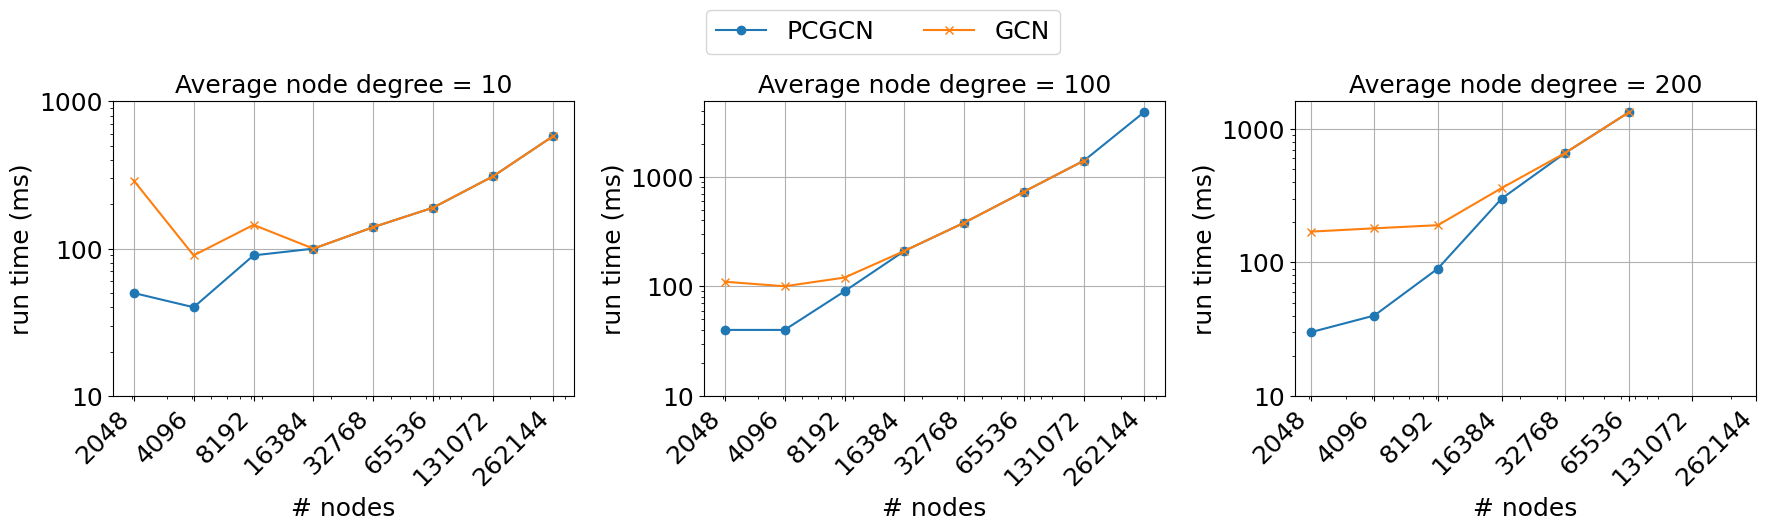

In [19]:
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Group by m values
for i, m in enumerate([10, 100, 200]):
    ax = axes[i]
    subset = tmp1[tmp1['m'] == m].copy()
    subset['n'] = subset['n'].astype(int)
    subset = subset.dropna(subset=['PCGCN', 'gcn'])

    ax.plot(subset['n'], subset['PCGCN'] * 1000, label='PCGCN', marker='o')
    ax.plot(subset['n'], subset['gcn'] * 1000, label='GCN', marker='x')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('# nodes')
    ax.set_xticks(subset['n'])
    ax.set_xticklabels(subset['n'], rotation=45, ha='right')
    ax.set_yticks([10, 100, 1000])
    ax.set_yticklabels(["10", "100", "1000"])
    ax.set_ylabel('run time (ms)')
    ax.set_title(f'Average node degree = {m}')
    ax.grid(True)

fig.legend(
    *axes[0].get_legend_handles_labels(),  # Get handles and labels from the first subplot
    loc='upper center',                     # Position below the plot
    ncol=2,                                # Number of columns in the legend
    bbox_to_anchor=(0.5, 1.1)            # Adjust vertical position
)
plt.tight_layout()
plt.show()
fig.savefig("best.png", dpi=300, bbox_inches='tight')
fig.savefig("best.pdf", dpi=300, bbox_inches='tight')

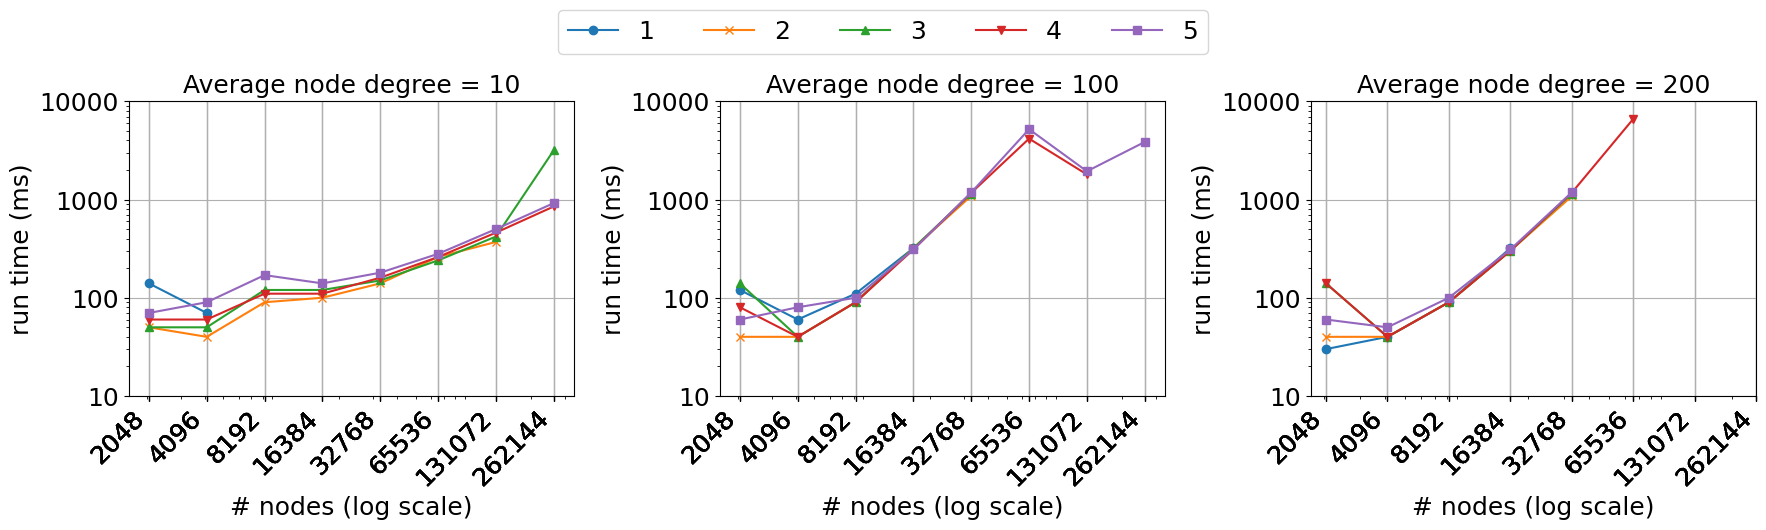

In [17]:
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
markers = ['o', 'x', '^', 'v', 's']

# Group by m values
for i, m in enumerate([10, 100, 200]):
    ax = axes[i]
    subset = df[df['m'] == m].copy()
    subset['n'] = subset['n'].astype(int)
    for k in range(1, 6):
        sk = subset[subset.k == k]
        x = sk.n
        y = sk.val * 1000
        ax.plot(x, y, label=str(k), marker=markers[k-1])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('# nodes (log scale)')
    ax.set_xticks(subset['n'])
    ax.set_xticklabels(subset['n'], rotation=45, ha='right')
    ax.set_ylabel('run time (ms)')
    ax.set_yticks([10, 100, 1000, 10000])
    ax.set_yticklabels(["10", "100", "1000", "10000"])
    ax.set_title(f'Average node degree = {m}')
    ax.grid(True)

fig.legend(
    *axes[0].get_legend_handles_labels(),  # Get handles and labels from the first subplot
    loc='upper center',                     # Position below the plot
    ncol=5,                                # Number of columns in the legend
    bbox_to_anchor=(0.5, 1.1)            # Adjust vertical position
)
plt.tight_layout()
plt.show()
fig.savefig("k.png", dpi=300, bbox_inches='tight')
fig.savefig("k.pdf", dpi=300, bbox_inches='tight')

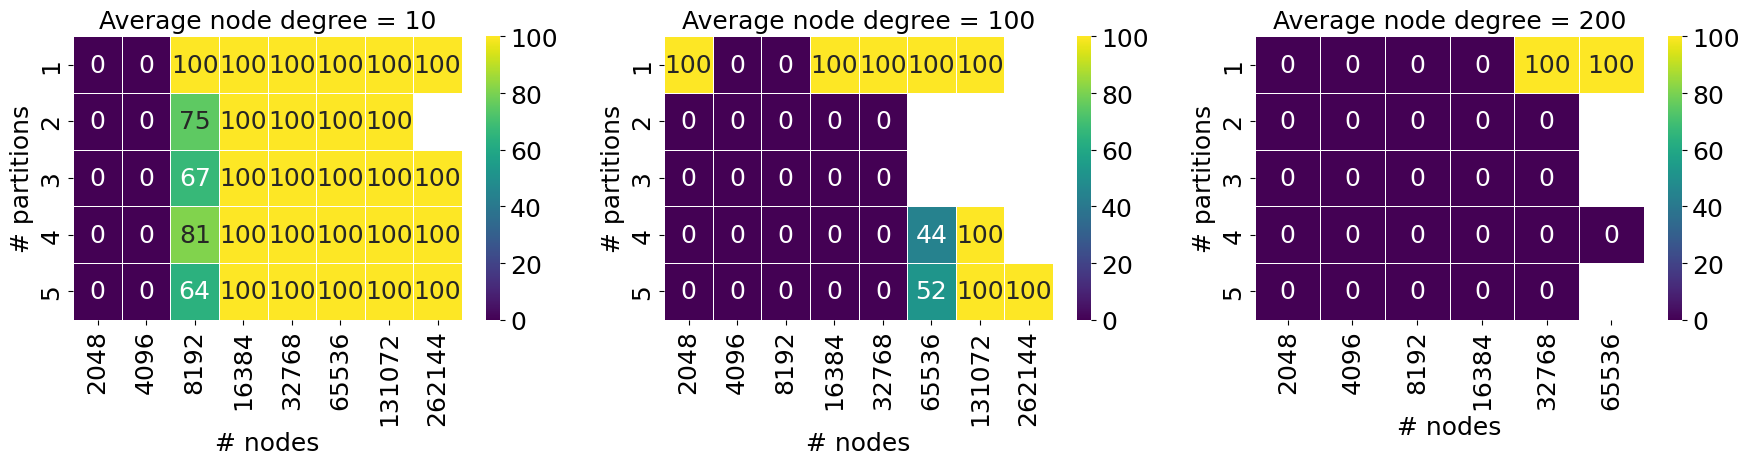

In [7]:
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Group by m values
for i, m in enumerate([10, 100, 200]):
    ax = axes[i]
    subset = df_all[df_all['m'] == m].copy()
    subset['n'] = subset['n'].astype(int)
    subset['pcg'] = (subset['n_sparse'] / (subset['k']**2) * 100).round(0)

    heatmap_data = subset.pivot(index='k', columns='n', values='pcg')

    # Create the heatmap
    sns.heatmap(
        heatmap_data,
        ax=ax,
        cmap='viridis',  # Choose a colormap
        annot=True,      # Show values in cells
        fmt='.0f',       # Format as integer
        cbar=True,       # Show color bar
        linewidths=0.5,  # Add lines between cells
        vmin=0,
        vmax=100
    )

    # Set labels and title
    ax.set_title(f'Average node degree = {m}')
    ax.set_xlabel('# nodes')
    ax.set_ylabel('# partitions')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()
fig.savefig("sparse.png", dpi=300, bbox_inches='tight')
fig.savefig("sparse.pdf", dpi=300, bbox_inches='tight')